# Heat Conduction Derivations from Lee, Section 13.3

This notebook develops the two main derivations from Lee, Section 13.3:

1. **Steady radial heat conduction in a cylindrical fuel rod with uniform volumetric heat generation**.
2. **Steady heat conduction through a composite wall**, including the extension to a cylindrical fuel rod with fuel, gap, clad, and coolant regions.



## Governing idea: steady energy conservation plus Fourier's law

For steady heat conduction, conservation of energy says that the net outward heat flow from a small control volume balances the heat generated inside it. Fourier's law relates heat flux to the temperature gradient:

$$\mathbf{q}=-k\nabla T.$$

The first derivation uses the radial cylindrical divergence operator. The second uses 1-D slab geometry and then translates the result into a thermal-resistance form useful for cylindrical fuel rods.


# 1. Heat conduction in a cylindrical fuel rod

## Problem setup

Consider a long cylindrical fuel rod of radius $a$ and length $L$. Assume:

- steady state,
- radial conduction only,
- uniform volumetric heat generation rate $S$,
- prescribed surface temperature $T_s$ at $r=a$,
- symmetry at the centerline, so the radial heat flux is finite and $q_r(0)=0$.

The 1-D radial energy equation is

$$\frac{1}{r}\frac{d}{dr}\left(rq_r\right)=S,$$

with Fourier's law

$$q_r=-k(T)\frac{dT}{dr}.$$


## Step 1: integrate the radial heat-balance equation

Multiply the radial balance by $r$:

$$\frac{d}{dr}\left(rq_r\right)=Sr.$$

Integrate from $0$ to $r$:

$$rq_r(r)-0=\int_0^r Sr'\,dr'=\frac{Sr^2}{2}.$$

Therefore,

$$q_r(r)=\frac{Sr}{2}.$$

This result has a simple interpretation: the heat crossing a cylindrical surface at radius $r$ equals the heat generated inside that radius, divided by the cylindrical surface area.


## Step 2: combine with Fourier's law

Using $q_r=-k(T)dT/dr$ gives

$$-k(T)\frac{dT}{dr}=\frac{Sr}{2}.$$

Rearrange and integrate from the rod surface $r=a$, where $T=T_s$, inward to an arbitrary radius $r$, where $T=T(r)$:

$$\int_{T_s}^{T(r)} k(T')\,dT'=\frac{S}{2}\int_r^a r'\,dr'.$$

Thus,

$$\int_{T_s}^{T(r)} k(T')\,dT'=\frac{Sa^2}{4}\left(1-\frac{r^2}{a^2}\right).$$


## Step 3: express the result in terms of linear heat generation rate

The total heat generated in a length $L$ of rod is

$$P=S\pi a^2L,$$

so the linear heat generation rate is

$$\frac{P}{L}=S\pi a^2.$$

Substitution gives

$$\int_{T_s}^{T(r)} k(T')\,dT'=\frac{P/L}{4\pi}\left(1-\frac{r^2}{a^2}\right).$$

At the centerline, $r=0$ and $T=T_c$, so

$$\int_{T_s}^{T_c} k(T')\,dT'=\frac{P/L}{4\pi}.$$

This shows why the allowed linear heat generation rate is governed by the allowable temperature rise from surface to centerline.


## Special case: constant thermal conductivity

If $k$ is approximately constant over the relevant temperature interval,

$$k\left[T(r)-T_s\right]=\frac{P/L}{4\pi}\left(1-\frac{r^2}{a^2}\right),$$

so the temperature profile is parabolic:

$$T(r)=T_s+\frac{P/L}{4\pi k}\left(1-\frac{r^2}{a^2}\right).$$

The centerline temperature is

$$T_c=T_s+\frac{P/L}{4\pi k}.$$


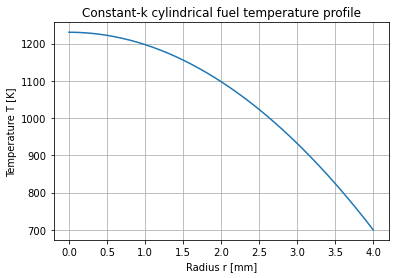

In [2]:
# Example: plot the constant-k parabolic temperature profile
import numpy as np
import matplotlib.pyplot as plt

# Representative values for illustration only
radius_m = 4.0e-3          # fuel radius [m]
linear_power = 20_000      # P/L [W/m]
k = 3.0                    # thermal conductivity [W/(m K)]
T_surface = 700.0          # surface temperature [K]

r = np.linspace(0, radius_m, 200)
T = T_surface + linear_power/(4*np.pi*k)*(1 - (r/radius_m)**2)

plt.figure(figsize=(6,4))
plt.plot(r*1e3, T)
plt.xlabel('Radius r [mm]')
plt.ylabel('Temperature T [K]')
plt.title('Constant-k cylindrical fuel temperature profile')
plt.grid(True)
plt.show()


## Temperature-dependent conductivity

When $k$ depends on temperature, the parabolic closed form no longer applies directly. Define the conductivity integral

$$F(T)=\int_0^T k(T')\,dT'.$$

Then

$$F(T(r))-F(T_s)=\frac{P/L}{4\pi}\left(1-\frac{r^2}{a^2}\right).$$

A numerical calculation can evaluate the right-hand side at each $r$ and solve for the temperature $T(r)$ by inverting $F(T)$.


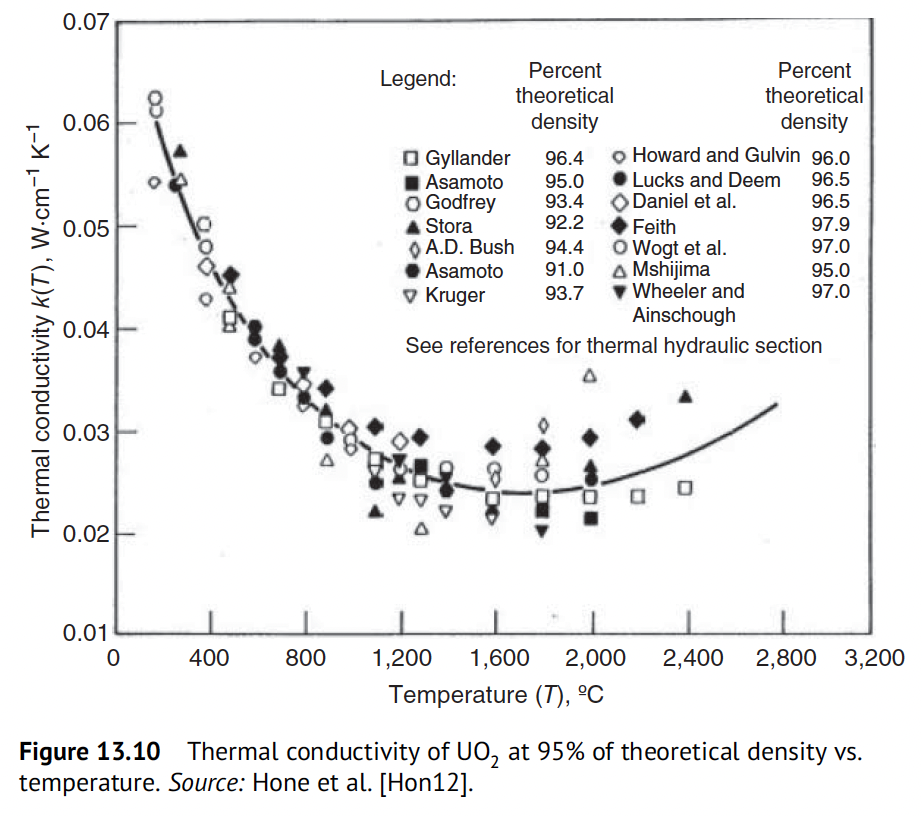

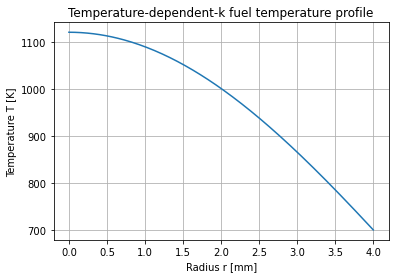

Centerline temperature = 1121.7 K


In [3]:
# Example: numerical inversion for temperature-dependent UO2 conductivity
# Correlation form shown in the source excerpt; T is in K, k in W/(m K).
from scipy.integrate import quad
from scipy.optimize import brentq

def k_uo2(T):
    return 18.86/(1 + 4.49e-3*T) + 8.775e-11*(T - 273.0)**3

def F(T):
    return quad(k_uo2, 0.0, T, limit=100)[0]

rhs = linear_power/(4*np.pi)*(1 - (r/radius_m)**2)
F_surface = F(T_surface)

T_variable_k = np.array([
    brentq(lambda temp: F(temp) - F_surface - val, T_surface, 4000.0)
    for val in rhs
])

plt.figure(figsize=(6,4))
plt.plot(r*1e3, T_variable_k)
plt.xlabel('Radius r [mm]')
plt.ylabel('Temperature T [K]')
plt.title('Temperature-dependent-k fuel temperature profile')
plt.grid(True)
plt.show()

print(f'Centerline temperature = {T_variable_k[0]:.1f} K')


# 2. Heat conduction through a composite wall

## Source geometry

The slab-wall figure below shows three solid layers with different thicknesses and thermal conductivities, followed by convective heat transfer to a fluid.


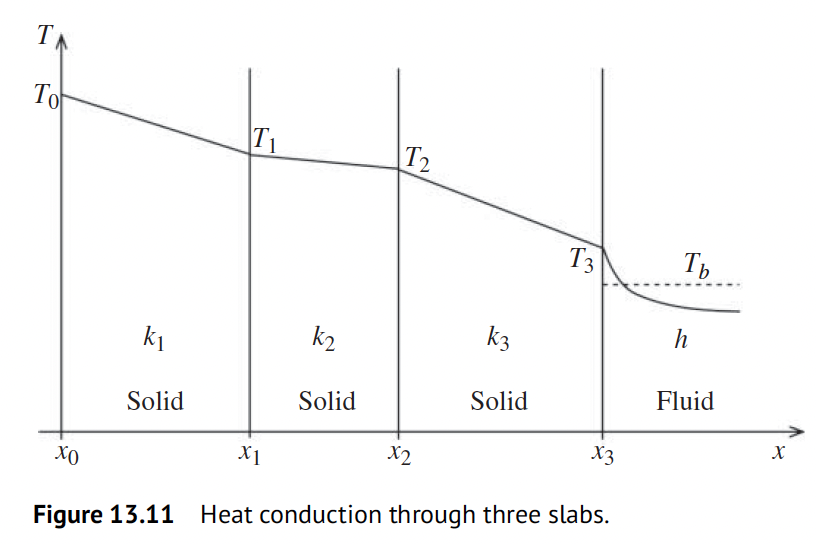

## Problem setup

Assume three planar layers. Let the interfaces be at $x_0,x_1,x_2,x_3$, with $x_0=0$. Each layer $i$ has thickness

$$\Delta x_i=x_i-x_{i-1}$$

and thermal conductivity $k_i$. There is no internal heat generation in the layers. The left boundary is held at temperature $T_0$, and the right boundary loses heat to a fluid at bulk temperature $T_b$ with heat-transfer coefficient $h$.

With no generation, steady 1-D conservation gives

$$\frac{dq}{dx}=0.$$

Therefore, the heat flux $q_0$ is constant through every layer and through the convective boundary.


## Step 1: write the temperature drops across each resistance

For layer $i$,

$$q_0 = -k_i\frac{T_i-T_{i-1}}{x_i-x_{i-1}},$$

so the temperature drop across that layer is

$$T_{i-1}-T_i=q_0\frac{\Delta x_i}{k_i}.$$

The convective boundary gives

$$q_0=h(T_3-T_b),$$

or

$$T_3-T_b=q_0\frac{1}{h}.$$


## Step 2: add the temperature drops

The total temperature difference from the hot boundary to the bulk fluid is the sum of the drops:

$$T_0-T_b=(T_0-T_1)+(T_1-T_2)+(T_2-T_3)+(T_3-T_b).$$

Substitute the resistance expressions:

$$T_0-T_b=q_0\left(\sum_{i=1}^{3}\frac{\Delta x_i}{k_i}+\frac{1}{h}\right).$$


## Step 3: define the overall heat-transfer coefficient

Define $U$ through

$$q_0=U(T_0-T_b).$$

Combining this with the previous equation gives

$$U=\left(\sum_{i=1}^{3}\frac{\Delta x_i}{k_i}+\frac{1}{h}\right)^{-1}.$$

This is the thermal-resistance analogy: conduction and convection resistances in series add, and the overall coefficient is the inverse of the total resistance.


In [3]:
# Example: compute U for a three-layer slab wall
thicknesses = np.array([2.0e-3, 1.0e-3, 0.6e-3])  # [m]
conductivities = np.array([15.0, 1.5, 20.0])      # [W/(m K)]
h = 10_000.0                                      # [W/(m^2 K)]

R_cond = thicknesses / conductivities
R_conv = 1/h
U = 1/(R_cond.sum() + R_conv)
print(f'U = {U:.1f} W/(m^2 K)')
print('Individual conduction resistances [m^2 K/W]:', R_cond)
print(f'Convection resistance [m^2 K/W]: {R_conv:.3e}')


U = 1075.3 W/(m^2 K)
Individual conduction resistances [m^2 K/W]: [1.33333333e-04 6.66666667e-04 3.00000000e-05]
Convection resistance [m^2 K/W]: 1.000e-04


# Extension: cylindrical fuel rod with gap, clad, and coolant

The source then maps the same resistance concept onto a cylindrical fuel rod. The figure below shows the fuel pellet, gap, clad, and coolant regions.


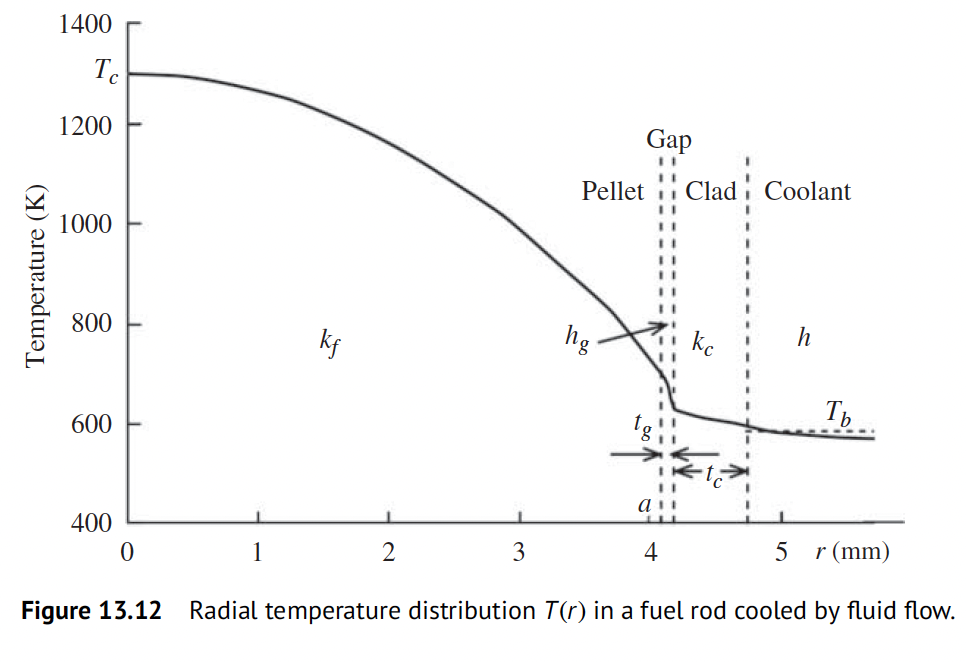

## Overall coefficient for the cylindrical fuel rod

Let:

- $a$ be the fuel radius,
- $t_g$ be the gap thickness,
- $t_c$ be the clad thickness,
- $k_f$ be the fuel thermal conductivity,
- $k_c$ be the clad thermal conductivity,
- $h_g$ be the gap conductance,
- $h$ be the coolant-side heat-transfer coefficient,
- $T_c$ be the fuel centerline temperature,
- $T_b$ be the coolant bulk temperature.

The heat flux into the coolant can be expressed as

$$q=U_c(T_c-T_b).$$

The corresponding overall coefficient is

$$U_c=\left[\frac{a}{2k_f}+\frac{1}{h_g}+\frac{a}{k_c}\ln\left(\frac{a+t_g+t_c}{a+t_g}\right)+\frac{a}{a+t_g+t_c}\frac{1}{h}\right]^{-1}.$$

Each term inside the brackets is a resistance contribution, normalized so that $U_c$ multiplies the temperature difference between the fuel centerline and the coolant bulk temperature.


In [4]:
# Example: cylindrical overall heat-transfer coefficient U_c
# Representative values for illustration only
a = 4.0e-3       # fuel radius [m]
t_g = 80e-6      # gap thickness [m]
t_c = 0.57e-3    # clad thickness [m]
k_f = 3.0        # fuel conductivity [W/(m K)]
k_c = 16.0       # clad conductivity [W/(m K)]
h_g = 7_000.0    # gap conductance [W/(m^2 K)]
h_cool = 25_000.0 # coolant heat transfer coefficient [W/(m^2 K)]

R_fuel = a/(2*k_f)
R_gap = 1/h_g
R_clad = a/k_c*np.log((a+t_g+t_c)/(a+t_g))
R_cool = a/(a+t_g+t_c)/h_cool
U_c = 1/(R_fuel + R_gap + R_clad + R_cool)

print(f'U_c = {U_c:.1f} W/(m^2 K)')
for name, value in [('fuel', R_fuel), ('gap', R_gap), ('clad', R_clad), ('coolant', R_cool)]:
    print(f'{name:7s} resistance contribution = {value:.3e} m^2 K/W')


U_c = 1140.7 W/(m^2 K)
fuel    resistance contribution = 6.667e-04 m^2 K/W
gap     resistance contribution = 1.429e-04 m^2 K/W
clad    resistance contribution = 3.269e-05 m^2 K/W
coolant resistance contribution = 3.441e-05 m^2 K/W


## Key takeaways

- In a uniformly heated cylinder with constant $k$, the radial temperature profile is parabolic.
- The centerline-to-surface temperature rise depends on the linear heat generation rate $P/L$, not directly on the rod radius, as long as volumetric heat generation is uniform.
- When $k$ varies with temperature, the same integral balance applies, but the temperature profile must generally be obtained by numerical inversion.
- Composite conduction problems are naturally interpreted as thermal resistances in series.
- The fuel-gap-clad-coolant system adds fuel conduction, gap conductance, clad conduction, and coolant convection into a single overall coefficient.
